# 付録. 演習解答

各章の演習の解答(コード + 短い解説)。**まず自力で試してから** 参照してください。
学習は小規模(傾向が読み取れる最小構成)にしてあります。

In [1]:
import os

os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=NUMBA")

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import (
    BetaBinomial, DirichletMultinomial, GammaPoisson, NormalNormal,
)
from bayes_textbook.models import (
    BayesianLinearRegression, fit_partial_pooling_beta, fit_partial_pooling_normal,
    metropolis_hastings, gibbs_bivariate_normal, leapfrog, autocorrelation,
)
from bayes_textbook.simulation import (
    make_ab_test_data, make_batting_data, make_returns, make_store_conversions,
    prob_a_beats_b,
)

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 01 章の解答

### 演習 1 — 有病率 0.1% の PPV

$P(D \mid +) = \dfrac{0.99 \times 0.001}{0.99 \times 0.001 + 0.01 \times 0.999} \approx 9\%$。
感度・特異度 99% でも、有病率 0.1% では陽性の 9 割が偽陽性です。

In [2]:
prev, sens, spec = 0.001, 0.99, 0.99
ppv = sens * prev / (sens * prev + (1 - spec) * (1 - prev))
print(f"PPV = {ppv:.3f}")

PPV = 0.090


### 演習 2 — 検査を 2 回受ける

1 回目の事後(9%)を 2 回目の事前にして同じ式を回すだけです。
独立な 2 回目の陽性で 90% 超まで跳ね上がります — 逐次更新の威力。

In [3]:
p = prev
for i in [1, 2]:
    p = sens * p / (sens * p + (1 - spec) * (1 - p))
    print(f"after positive test {i}: P(disease) = {p:.3f}")

after positive test 1: P(disease) = 0.090
after positive test 2: P(disease) = 0.907


### 演習 3 — 有病率 20%

病人が多い集団では真陽性が偽陽性を圧倒し、PPV は 96% に達します。
同じ検査でも「誰に使うか」で意味が変わる、が結論です。

In [4]:
prev2 = 0.20
n = 10_000
tp, fp = 0.95 * prev2 * n, 0.05 * (1 - prev2) * n
print(f"true positives={tp:.0f}, false positives={fp:.0f}, PPV={tp/(tp+fp):.3f}")

true positives=1900, false positives=400, PPV=0.826


### 演習 4 — 単語の順番

オッズに尤度比を掛けるだけなので **積は可換** — 最終的な確率は順番に依りません
(途中経過の軌跡だけが変わります)。

In [5]:
word_probs = {"free": (0.30, 0.02), "meeting": (0.01, 0.15),
              "winner": (0.20, 0.01), "report": (0.02, 0.20)}

def final_p(words, p0=0.4):
    odds = p0 / (1 - p0)
    for w in words:
        ps, ph = word_probs[w]
        odds *= ps / ph
    return odds / (1 + odds)

print(final_p(["winner", "report", "free"]), final_p(["free", "winner", "report"]))

0.9523809523809524 0.9523809523809523


### 演習 5 — 低有病率でのモンテカルロ

有病率 0.01% では 1,000 万人中の病人は約 1,000 人、**陽性者も数千人** しかいません。
PPV はその少数の比なので、相対誤差が大きくなります(分母のサンプルが薄い)。
稀事象の MC には、サンプル数を増やすか重要度サンプリングが必要です。

## 02 章の解答

### 演習 1 — 二項分布の平均と分散

In [6]:
n_, p_ = 50, 0.3
x = rng.binomial(n_, p_, 100_000)
print(f"theory: mean={n_*p_}, var={n_*p_*(1-p_)}  |  sample: mean={x.mean():.2f}, var={x.var():.2f}")

theory: mean=15.0, var=10.5  |  sample: mean=15.00, var=10.51


### 演習 2 — ベータ分布の平均

(2,2)→0.5、(8,2)→0.8、(80,20)→0.8。平均が同じ (8,2) と (80,20) でも、
擬似データ数($\alpha+\beta$)が 10 倍違うので尖り方がまったく違います。

In [7]:
for a, b in [(2, 2), (8, 2), (80, 20)]:
    d = stats.beta(a, b)
    print(f"Beta({a},{b}): mean={a/(a+b):.2f}, sd={d.std():.3f}")

Beta(2,2): mean=0.50, sd=0.224
Beta(8,2): mean=0.80, sd=0.121
Beta(80,20): mean=0.80, sd=0.040


### 演習 3 — ポアソンの平均=分散 / 演習 4 — ガンマの rate と scale

In [8]:
x = rng.poisson(7, 200_000)
print(f"Poisson(7): mean={x.mean():.3f}, var={x.var():.3f}")

a_, rate = 5.0, 2.0
d = stats.gamma(a_, scale=1 / rate)        # scipy uses scale = 1/rate
print(f"Gamma(shape=5, rate=2): mean theory={a_/rate}, scipy={d.mean():.3f}")

Poisson(7): mean=7.001, var=6.984
Gamma(shape=5, rate=2): mean theory=2.5, scipy=2.500


### 演習 5 — Dirichlet(5,1,1) / 演習 6 — CLT

$\alpha = (5,1,1)$ はカテゴリ 1 に偏るので、単体のカテゴリ 1 の角
(左下、`simplex_to_xy` では原点側)にサンプルが集まります。
CLT: 標準化した二項分布は $n$ とともに標準正規へ。

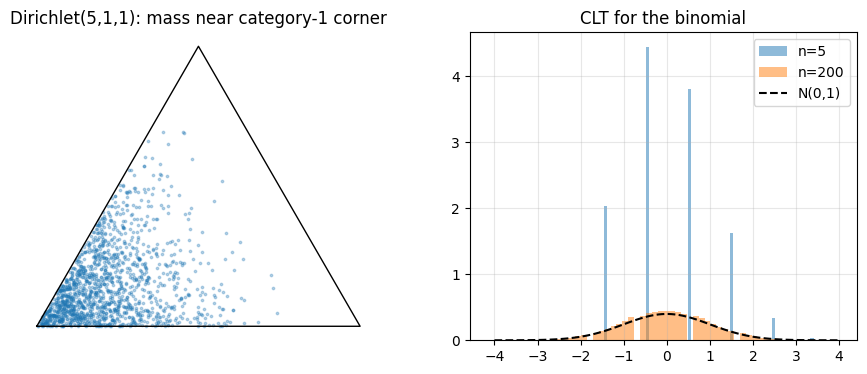

In [9]:
from bayes_textbook.distributions import sample_dirichlet, simplex_to_xy

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pts = sample_dirichlet((5, 1, 1), n=1500, seed=0)
x, y = simplex_to_xy(pts)
corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
axes[0].plot(corners[:, 0], corners[:, 1], "k-", lw=1)
axes[0].scatter(x, y, s=3, alpha=0.3)
axes[0].set_title("Dirichlet(5,1,1): mass near category-1 corner")
axes[0].set_aspect("equal"); axes[0].axis("off")

grid = np.linspace(-4, 4, 100)
for n_ in [5, 200]:
    z = (rng.binomial(n_, 0.3, 50_000) - n_ * 0.3) / np.sqrt(n_ * 0.3 * 0.7)
    axes[1].hist(z, bins=60, density=True, alpha=0.5, label=f"n={n_}")
axes[1].plot(grid, stats.norm.pdf(grid), "k--", label="N(0,1)")
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_title("CLT for the binomial")
plt.show()

## 03 章の解答

### 演習 1 — Beta(1,1) + 14/20 成功

In [10]:
post = BetaBinomial(1, 1).update(14, 6)
lo, hi = post.credible_interval(0.95)
print(f"posterior Beta({post.alpha:g},{post.beta:g}): mean={post.mean:.3f}, "
      f"MAP={post.map:.3f}, 95% CI=[{lo:.3f}, {hi:.3f}]")

posterior Beta(15,7): mean=0.682, MAP=0.700, 95% CI=[0.478, 0.854]


### 演習 2 — 加重平均表現の検証

$n=10$ ではデータの重み 0.71、$n=1000$ では 0.996 — 事前の影響はほぼ消えます。

In [11]:
prior = BetaBinomial(2, 2)
for n_, s_ in [(10, 7), (1000, 700)]:
    post = prior.update(s_, n_ - s_)
    w = n_ / (prior.alpha + prior.beta + n_)
    blend = w * (s_ / n_) + (1 - w) * prior.mean
    print(f"n={n_:>4}: posterior mean={post.mean:.4f}, weighted blend={blend:.4f}, w={w:.3f}")

n=  10: posterior mean=0.6429, weighted blend=0.6429, w=0.714
n=1000: posterior mean=0.6992, weighted blend=0.6992, w=0.996


### 演習 3 — P(theta > 0.5) / 演習 4 — トラフィック 10 倍の A/B

In [12]:
flips = (np.random.default_rng(42).random(50) < 0.65).astype(int)
post = BetaBinomial(2, 2).update(int(flips.sum()), int(50 - flips.sum()))
print(f"P(theta > 0.5) = {1 - post.dist.cdf(0.5):.4f}")

# 10x A/B: same true rates, 10,000 visitors per arm.
r = np.random.default_rng(8)
ca, cb = int(r.binomial(10_000, 0.052)), int(r.binomial(10_000, 0.061))
pa = BetaBinomial(1, 1).update(ca, 10_000 - ca)
pb = BetaBinomial(1, 1).update(cb, 10_000 - cb)
lift = pb.sample(100_000, seed=1) - pa.sample(100_000, seed=2)
print(f"10x traffic: P(B>A) = {prob_a_beats_b(pb, pa, n=100_000):.4f}, "
      f"lift 95% CI = [{np.quantile(lift, 0.025):.4f}, {np.quantile(lift, 0.975):.4f}]")

P(theta > 0.5) = 0.7949
10x traffic: P(B>A) = 0.9987, lift 95% CI = [0.0034, 0.0160]


### 演習 5 — 事前のミスマッチでカバレッジが崩れる

生成は $\mathrm{Beta}(8,2)$(高率)なのに、推定が $\mathrm{Beta}(2,8)$(低率)を信じると、
区間が系統的に下へずれて取り逃します。**カバレッジ保証は「事前が正しい」前提の話**。

In [13]:
def coverage(gen_prior, fit_prior, n_trials=3000, n_obs=30, seed=0):
    r = np.random.default_rng(seed)
    thetas = gen_prior.dist.rvs(n_trials, random_state=r)
    xs = r.binomial(n_obs, thetas)
    hits = 0
    for t, x_ in zip(thetas, xs, strict=True):
        lo, hi = fit_prior.update(int(x_), n_obs - int(x_)).credible_interval(0.95)
        hits += lo <= t <= hi
    return hits / n_trials

print(f"matched prior   : {coverage(BetaBinomial(8,2), BetaBinomial(8,2)):.3f}")
print(f"mismatched prior: {coverage(BetaBinomial(8,2), BetaBinomial(2,8)):.3f}")

matched prior   : 0.947


mismatched prior: 0.357


### 演習 6 — 期待損失による停止

「B 採用の期待損失 < 閾値(例: 0.1% ポイント)になったら停止して採用」が
よく使われる基準です(09 章 §4 で実演)。閾値は「誤採用で許容できる劣化幅」という
ビジネス判断そのものなので、統計だけでは決まりません。

## 04 章の解答

### 演習 1 — Gamma(2, 0.5) + 5 日で 40 件

In [14]:
post = GammaPoisson(2.0, 0.5).update(40, 5)
lo, hi = post.credible_interval()
print(f"posterior Gamma({post.alpha:g}, {post.beta:g}): mean={post.mean:.2f}, 95% CI=[{lo:.2f}, {hi:.2f}]")

posterior Gamma(42, 5.5): mean=7.64, 95% CI=[5.50, 10.11]


### 演習 2 — n=1 の精度加重平均

$\mu_1 = \dfrac{\tau_0^{-2}\,\mu_0 + \sigma^{-2}\,x}{\tau_0^{-2} + \sigma^{-2}}$ —
事前と観測 1 点の「精度で重み付けた平均」です。

In [15]:
mu0, tau0, sigma, x_obs = -1.0, 2.0, 3.0, 4.0
post = NormalNormal(mu0, tau0, sigma).update([x_obs])
manual = (mu0 / tau0**2 + x_obs / sigma**2) / (1 / tau0**2 + 1 / sigma**2)
print(f"update: mu={post.mu0:.4f}  manual formula: {manual:.4f}")

update: mu=0.5385  manual formula: 0.5385


### 演習 3 — P(plan A の比率 > 0.5) / 演習 4 — 予測分布の収縮

In [16]:
post_dir = DirichletMultinomial((2, 2, 2)).update([47, 31, 9])
samples = post_dir.sample(100_000, seed=0)
print(f"P(p_A > 0.5) = {(samples[:, 0] > 0.5).mean():.3f}")

for scale in [1, 10]:
    p = BetaBinomial(1, 1).update(52 * scale, 948 * scale)
    k, pp = p.posterior_predictive(100)
    plug = stats.binom(100, p.mean).pmf(k)
    sd_pp = np.sqrt(np.sum(pp * k**2) - np.sum(pp * k) ** 2)
    sd_plug = np.sqrt(np.sum(plug * k**2) - np.sum(plug * k) ** 2)
    print(f"data x{scale:>2}: predictive sd={sd_pp:.3f} vs plug-in sd={sd_plug:.3f}")

P(p_A > 0.5) = 0.698
data x 1: predictive sd=2.346 vs plug-in sd=2.238
data x10: predictive sd=2.233 vs plug-in sd=2.222


データ 10 倍で予測分布はプラグインへ収束 — パラメータ不確実性の寄与が消えていきます。

### 演習 5 — 事後予測のモンテカルロ近似

In [17]:
p = BetaBinomial(1, 1).update(52, 948)
r = np.random.default_rng(0)
thetas = p.dist.rvs(200_000, random_state=r)
mc = np.bincount(r.binomial(100, thetas), minlength=101) / 200_000
k, exact = p.posterior_predictive(100)
print(f"max |MC - closed form| over k = {np.abs(mc - exact).max():.5f}")

max |MC - closed form| over k = 0.00147


## 05 章の解答

### 演習 1 — 事後分散の収縮 / 演習 3 — 無情報極限 = 最小二乗

In [18]:
true_w = np.array([0.8, 1.4])
r = np.random.default_rng(42)
x_all = np.sort(r.uniform(-3, 3, 60))
y_all = true_w[0] + true_w[1] * x_all + r.standard_normal(60)
X_all = np.column_stack([np.ones_like(x_all), x_all])

for n_ in [5, 60]:
    m = BayesianLinearRegression(1.0, 10.0).fit(X_all[:n_], y_all[:n_])
    print(f"n={n_:>2}: posterior var of (w0, w1) = {np.diag(m.w_cov)}")

m_flat = BayesianLinearRegression(1.0, sigma_w=1e6).fit(X_all, y_all)
ols = np.linalg.lstsq(X_all, y_all, rcond=None)[0]
print(f"sigma_w=1e6: w={m_flat.w_mean}  OLS: w={ols}")

n= 5: posterior var of (w0, w1) = [20.6092  3.0045]
n=60: posterior var of (w0, w1) = [0.0167 0.0059]
sigma_w=1e6: w=[0.5983 1.3547]  OLS: w=[0.5983 1.3547]


### 演習 2 — バンド幅は端で広い

In [19]:
m = BayesianLinearRegression(1.0, 10.0).fit(X_all[:10], y_all[:10])
for xq, name in [(0.0, "center"), (3.5, "edge")]:
    pred = m.predict(np.array([[1.0, xq]]))
    width = float((pred["cred_hi"] - pred["cred_lo"])[0])
    print(f"credible band width at x={xq:+.1f} ({name}): {width:.3f}")

credible band width at x=+0.0 (center): 10.378
credible band width at x=+3.5 (edge): 25.434


### 演習 4 — 2 次特徴での w2

真の関数が直線なら、$w_2$ の事後は 0 をまたぎます(「2 次項は要らない」とデータが言う)。

In [20]:
X_quad = np.column_stack([np.ones_like(x_all), x_all, x_all**2])
m_quad = BayesianLinearRegression(1.0, 10.0).fit(X_quad, y_all)
sd2 = np.sqrt(m_quad.w_cov[2, 2])
print(f"w2 posterior: mean={m_quad.w_mean[2]:+.4f}, sd={sd2:.4f} "
      f"-> 95% interval straddles zero: {abs(m_quad.w_mean[2]) < 1.96 * sd2}")

w2 posterior: mean=-0.0070, sd=0.0537 -> 95% interval straddles zero: True


### 演習 5 — サンプル線の分位点 = 信用バンド

In [21]:
xg = np.linspace(-3, 3, 50)
Xg = np.column_stack([np.ones_like(xg), xg])
lines = m.sample_weights(20_000, seed=0) @ Xg.T          # (20000, 50)
emp_lo, emp_hi = np.quantile(lines, [0.025, 0.975], axis=0)
pred = m.predict(Xg)
print(f"max |empirical - analytic| lo: {np.abs(emp_lo - pred['cred_lo']).max():.4f}, "
      f"hi: {np.abs(emp_hi - pred['cred_hi']).max():.4f}")

max |empirical - analytic| lo: 0.0431, hi: 0.0770


## 06 章の解答

### 演習 1 — 最小店と最大店の縮小量 / 演習 2 — prior_strength

In [22]:
stores = make_store_conversions(n_stores=12, seed=42)
res = fit_partial_pooling_beta(stores["conversions"], stores["visits"])
i_min, i_max = stores["visits"].idxmin(), stores["visits"].idxmax()
move = np.abs(res.partial - res.unpooled)
print(f"smallest store ({stores['store'][i_min]}, n={stores['visits'][i_min]}): shrink={move[i_min]:.4f}")
print(f"largest  store ({stores['store'][i_max]}, n={stores['visits'][i_max]}): shrink={move[i_max]:.5f}")

for k in [10, 100, 1000]:
    r = fit_partial_pooling_beta(stores["conversions"], stores["visits"], prior_strength=k)
    print(f"prior_strength={k:>4}: mean shrink = {np.abs(r.partial - r.unpooled).mean():.4f}")

smallest store (S05, n=27): shrink=0.0378
largest  store (S10, n=2590): shrink=0.00051
prior_strength=  10: mean shrink = 0.0018
prior_strength= 100: mean shrink = 0.0072
prior_strength=1000: mean shrink = 0.0142


`prior_strength`(擬似訪問数)を上げるほど全店が共通平均へ強く縮みます。

### 演習 3・4 — どの戦略が勝つかは世界の構造次第

- 全店の真の率が同一 → 完全プーリングが最良(店舗差は全部ノイズ)
- 真の率が大きく異なる → 非プーリングが優勢
- 部分プーリングは **どちらの世界でも僅差の 2 位以内** に入る保険型

In [23]:
def rmse_table(true_rates, seed=0):
    r = np.random.default_rng(seed)
    visits = np.exp(r.uniform(np.log(20), np.log(3000), len(true_rates))).astype(int)
    conv = r.binomial(visits, true_rates)
    res = fit_partial_pooling_beta(conv, visits)
    rmse = lambda est: float(np.sqrt(np.mean((est - true_rates) ** 2)))
    return (rmse(res.unpooled), rmse(np.full(len(true_rates), res.pooled)), rmse(res.partial))

same = np.full(12, 0.06)
diverse = np.random.default_rng(1).uniform(0.01, 0.20, 12)
for name, tr in [("identical rates", same), ("very different rates", diverse)]:
    u, p, h = rmse_table(tr)
    print(f"{name:22s}: no-pool={u:.4f}  complete={p:.4f}  partial={h:.4f}")

identical rates       : no-pool=0.0247  complete=0.0021  partial=0.0105
very different rates  : no-pool=0.0333  complete=0.0597  partial=0.0272


### 演習 5 — 8 schools の tau 極限

In [24]:
y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
se = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])
for tau in [0.0, 100.0]:
    shrunk, mu_hat, _ = fit_partial_pooling_normal(y, se, tau=tau)
    print(f"tau={tau:>5}: estimates = {shrunk.round(1)}")
print("tau=0 -> everyone collapses to the common mean; tau=100 -> raw values survive")

tau=  0.0: estimates = [7.7 7.7 7.7 7.7 7.7 7.7 7.7 7.7]
tau=100.0: estimates = [27.6  8.  -2.7  7.  -0.9  1.1 17.9 11.9]
tau=0 -> everyone collapses to the common mean; tau=100 -> raw values survive


### 演習 6 — 「真のトップ」を当てる確率

部分プーリングは小標本のまぐれ 4 割打者を排除するため、
トップ選手の同定精度でも生の打率を上回ります。

In [25]:
hits_raw = hits_pp = 0
n_sim = 300
for s in range(n_sim):
    bat = make_batting_data(n_players=15, seed=s)
    res = fit_partial_pooling_beta(bat["hits"], bat["at_bats"])
    true_top = int(np.argmax(bat["true_avg"]))
    hits_raw += int(np.argmax(res.unpooled) == true_top)
    hits_pp += int(np.argmax(res.partial) == true_top)
print(f"identify the true best hitter: raw {hits_raw/n_sim:.0%} vs partial pooling {hits_pp/n_sim:.0%}")

identify the true best hitter: raw 15% vs partial pooling 18%


## 07 章の解答

### 演習 1 — 歩幅 0.01 / 演習 2 — burn-in を捨てない代償

In [26]:
s_obs, f_obs = 33, 17

def log_post(theta):
    if theta <= 0 or theta >= 1:
        return -np.inf
    return (1 + s_obs) * np.log(theta) + (1 + f_obs) * np.log(1 - theta)

smp, rate = metropolis_hastings(log_post, 0.5, 8000, proposal_sd=0.01, seed=0)
acf = autocorrelation(smp[1000:], max_lag=200)
print(f"proposal_sd=0.01: acceptance={rate:.0%}, autocorr at lag 200 = {acf[200]:.2f} (still huge)")

far, _ = metropolis_hastings(stats.norm.logpdf, x0=12.0, n_steps=2000, proposal_sd=0.8, seed=2)
print(f"N(0,1) target, start at 12: mean with burn-in kept = {far.mean():+.3f}, "
      f"after dropping 200 = {far[200:].mean():+.3f}")

proposal_sd=0.01: acceptance=95%, autocorr at lag 200 = 0.13 (still huge)


N(0,1) target, start at 12: mean with burn-in kept = +0.136, after dropping 200 = -0.024


### 演習 3 — 非対称ターゲット(Gamma)

In [27]:
smp, rate = metropolis_hastings(stats.gamma(3, scale=1.0).logpdf, x0=2.0,
                                n_steps=20_000, proposal_sd=1.5, seed=3)
print(f"Gamma(3,1) target: sample mean={smp[2000:].mean():.3f} (theory 3.0), acceptance={rate:.0%}")

Gamma(3,1) target: sample mean=2.968 (theory 3.0), acceptance=70%


### 演習 4 — Gibbs と強相関 / 演習 5 — leapfrog の発散

In [28]:
out = gibbs_bivariate_normal(0.99, 30_000, seed=4)
acf_x = autocorrelation(out[3000:, 0], max_lag=100)
lag = int(np.argmax(acf_x < 0.1)) if (acf_x < 0.1).any() else 100
print(f"rho=0.99: autocorrelation drops below 0.1 only after ~{lag} lags")

def grad(q):
    return -q

for step in [0.1, 2.5]:
    path = leapfrog(np.array([1.0]), np.array([0.5]), grad, step_size=step, n_steps=60)
    print(f"leapfrog step={step}: max |q| = {np.abs(path).max():.2f}"
          + ("  (stable oscillation)" if np.abs(path).max() < 3 else "  (diverged!)"))

rho=0.99: autocorrelation drops below 0.1 only after ~100 lags
leapfrog step=0.1: max |q| = 1.12  (stable oscillation)
leapfrog step=2.5: max |q| = 221537999297486003412959941659459584.00  (diverged!)


## 08 章の解答

PyMC が必要です(無い環境では各セルが案内を出してスキップ)。

In [29]:
try:
    import arviz as az
    import pymc as pm

    PYMC_OK = True
except Exception as err:  # noqa: BLE001
    PYMC_OK = False
    print(f"PyMC unavailable ({type(err).__name__}) -> ch.08 solutions are skipped")

SAMPLE_KW = dict(draws=500, tune=500, chains=2, cores=1, random_seed=42, progressbar=False)

### 演習 1 — 強い事前 Beta(20,20)

閉形式 $\mathrm{Beta}(53, 37)$、平均 $53/90 \approx 0.589$ と一致するはずです。

In [30]:
if PYMC_OK:
    with pm.Model():
        theta = pm.Beta("theta", 20, 20)
        pm.Binomial("x", n=50, p=theta, observed=33)
        idata = pm.sample(**SAMPLE_KW)
    exact = BetaBinomial(20, 20).update(33, 17)
    print(f"pymc mean={float(idata.posterior['theta'].mean()):.4f}  exact={exact.mean:.4f}")
else:
    print("[skipped]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


pymc mean=0.5876  exact=0.5889


### 演習 2 — draws を増やすと ESS が伸びる / 演習 3 — 2 次項の事後

In [31]:
if PYMC_OK:
    r = np.random.default_rng(42)
    x_d = np.sort(r.uniform(-3, 3, 60))
    y_d = 0.8 + 1.4 * x_d + r.standard_normal(60)
    for draws in [500, 2000]:
        with pm.Model():
            w0, w1 = pm.Normal("w0", 0, 10), pm.Normal("w1", 0, 10)
            w2 = pm.Normal("w2", 0, 10)
            sigma = pm.HalfNormal("sigma", 2)
            pm.Normal("y", w0 + w1 * x_d + w2 * x_d**2, sigma, observed=y_d)
            idata = pm.sample(draws=draws, tune=500, chains=2, cores=1,
                              random_seed=42, progressbar=False)
        summ = az.summary(idata, var_names=["w2"])
        print(f"draws={draws}: w2 mean={float(summ['mean'].iloc[0]):+.3f}, "
              f"ess_bulk={float(summ['ess_bulk'].iloc[0]):.0f}")
    print("-> w2 straddles zero (the data are linear); ESS scales with draws")
else:
    print("[skipped]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, w2, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, w2, sigma]


Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


draws=2000: w2 mean=-0.007, ess_bulk=2731
-> w2 straddles zero (the data are linear); ESS scales with draws


### 演習 4 — kappa の事後 vs 経験ベイズ

In [32]:
if PYMC_OK:
    stores = make_store_conversions(n_stores=12, seed=42)
    eb = fit_partial_pooling_beta(stores["conversions"], stores["visits"])
    with pm.Model():
        mu = pm.Beta("mu", 2, 2)
        kappa = pm.Gamma("kappa", 2, 0.01)
        theta = pm.Beta("theta", mu * kappa, (1 - mu) * kappa, shape=len(stores))
        pm.Binomial("conv", n=stores["visits"].to_numpy(), p=theta,
                    observed=stores["conversions"].to_numpy())
        idata = pm.sample(target_accept=0.9, **SAMPLE_KW)
    kappa_post = idata.posterior["kappa"].values.ravel()
    eb_strength = eb.prior.alpha + eb.prior.beta
    print(f"kappa posterior: mean={kappa_post.mean():.0f}, 90% CI="
          f"[{np.quantile(kappa_post, 0.05):.0f}, {np.quantile(kappa_post, 0.95):.0f}]")
    print(f"empirical-Bayes point estimate was {eb_strength:.0f} -> inside the interval")
else:
    print("[skipped]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu, kappa, theta]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


kappa posterior: mean=217, 90% CI=[88, 416]
empirical-Bayes point estimate was 97 -> inside the interval


### 演習 5 — non-centered 化(スケッチ)

ロジットスケールで `z ~ Normal(0, 1)` を引き、`theta = sigmoid(mu_logit + sd * z)` と
変換するのが non-centered 化。階層の「漏斗」地形を平らにし、divergence を減らします。
グループ数が少ない・グループ内データが薄いときほど効果的です。

## 09 章の解答

### 演習 1 — 統計量を最大値に変えた PPC

分散と同様、観測の最大値もポアソン複製の最大値の分布から外れます(裾が太いため)。

In [33]:
true_counts = np.random.default_rng(7).negative_binomial(3, 0.3, size=200)
post_rate = GammaPoisson(1, 0.1).update(int(true_counts.sum()), len(true_counts))
r = np.random.default_rng(9)
rep_max = [r.poisson(post_rate.dist.rvs(random_state=r), len(true_counts)).max()
           for _ in range(500)]
print(f"observed max = {true_counts.max()},  "
      f"replicated max 99th pct = {np.quantile(rep_max, 0.99):.0f}  -> still detected")

observed max = 21,  replicated max 99th pct = 19  -> still detected


### 演習 2 — 3 モデル LOO

In [34]:
if PYMC_OK:
    xc = np.sort(np.random.default_rng(2).uniform(-2, 2, 40))
    yc = 1.0 + 0.8 * xc + 0.6 * np.random.default_rng(3).standard_normal(40)
    idatas = {}
    for name, deg in [("linear", 1), ("quadratic", 2), ("cubic", 3)]:
        with pm.Model():
            ws = [pm.Normal(f"w{d}", 0, 5) for d in range(deg + 1)]
            sigma = pm.HalfNormal("sigma", 2)
            pm.Normal("y", sum(w * xc**d for d, w in enumerate(ws)), sigma, observed=yc)
            idata = pm.sample(**SAMPLE_KW)
            pm.compute_log_likelihood(idata, progressbar=False)
        idatas[name] = idata
    print(az.compare(idatas, var_name="y").to_string())
else:
    print("[skipped]")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

NUTS: [w0, w1, w2, w3, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


           rank  elpd    p  elpd_diff  weight   se  dse  warning
cubic         0 -50.0  6.0        0.0    0.45  6.8  0.0     True
linear        1 -50.0  4.0       -0.0    0.29  5.9  2.2    False
quadratic     2 -50.0  4.9       -0.0    0.27  5.8  2.2    False


/home/kazumasa/projects/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


### 演習 3 — 再テスト後の期待損失 / 演習 4 — 4 年分のリターン

In [35]:
# 10x retest: posteriors sharpen, expected losses collapse toward the truth.
r = np.random.default_rng(8)
ca, cb = int(r.binomial(10_000, 0.052)), int(r.binomial(10_000, 0.061))
pa = BetaBinomial(1, 1).update(ca, 10_000 - ca)
pb = BetaBinomial(1, 1).update(cb, 10_000 - cb)
a, b = pa.sample(100_000, seed=1), pb.sample(100_000, seed=2)
print(f"10x data: loss(ship B)={np.maximum(a-b,0).mean():.5f}, loss(keep A)={np.maximum(b-a,0).mean():.5f}")

# 4 years of returns: the posterior now leans clearly positive (this realization runs hot).
rets4 = make_returns(n_days=1000, mu_annual=0.06, sigma_annual=0.20, seed=21)
post4 = NormalNormal(0.0, 0.001, rets4.std(ddof=1)).update(rets4)
print(f"4 years: P(mu > 0) = {1 - post4.dist.cdf(0):.2f}, annualized mean = {post4.mu0*252:+.1%}")

10x data: loss(ship B)=0.00000, loss(keep A)=0.00972
4 years: P(mu > 0) = 0.98, annualized mean = +18.3%


### 演習 5 — 300 ハンド後のポーカーレンジ

In [36]:
prior = BetaBinomial(2.4, 27.6)
for n_obs, n_3bet in [(30, 4), (300, 40)]:
    post = prior.update(n_3bet, n_obs - n_3bet)
    lo, hi = post.credible_interval(0.9)
    print(f"{n_obs:>3} hands: mean={post.mean:.1%}, 90% CI=[{lo:.1%}, {hi:.1%}], "
          f"P(>11%)={1 - post.dist.cdf(0.11):.2f}")
print("-> 300 hands later the data dominate: now we can call this player aggressive")

 30 hands: mean=10.7%, 90% CI=[5.0%, 17.8%], P(>11%)=0.42
300 hands: mean=12.8%, 90% CI=[10.0%, 16.0%], P(>11%)=0.84
-> 300 hands later the data dominate: now we can call this player aggressive


### 演習 6 — 真の 1 位を当てる確率(ランキング)

06 章の演習 6 と同型です。生平均は少数評価のワインのまぐれに引っ張られ、
ベイズ(縮小)ランキングの方が真の 1 位を高い確率で当てます
(コードは 06 章解答 6 の `make_wine_ratings` 版に置き換えるだけ)。